**class imbalance**

When one class dominant the other class. It means one class has so much data compare to others.

**why studying imbalance data is important in ML?**

i. Finance (fraud detection)

ii. Healthcare (rare disease prediction)

iii. Manufacturing (predicting defective items)

iv. Consumer internet (customer churn)

v. Environment science (predicting earthquake, volcano erruption etc)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report

In [2]:
np.random.seed(41)
centers = [(0, 0), (2, 2)]
cluster_std = [1.5, 1.5]

X, y = make_blobs(n_samples=[25, 375], centers=centers, cluster_std=cluster_std, random_state=41)

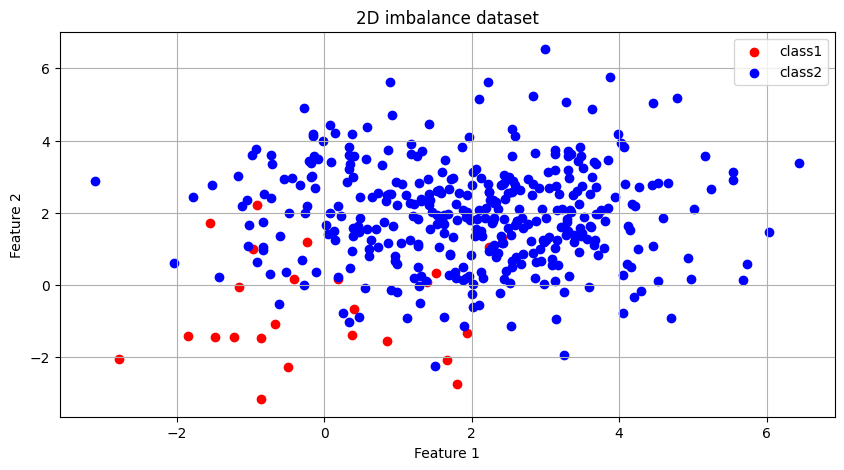

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='class1')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='class2')
#plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
plt.title("2D imbalance dataset")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.legend()
plt.show()

**Applying logistic regression without any correction**

In [7]:
from sklearn.linear_model import LogisticRegression

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [9]:
lr = LogisticRegression()

In [10]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

In [14]:
print('Classification Report:')
print(classification_report(y_test, y_pred))
print(roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         6
           1       0.95      1.00      0.97        74

    accuracy                           0.95        80
   macro avg       0.97      0.67      0.74        80
weighted avg       0.95      0.95      0.94        80

0.8558558558558558


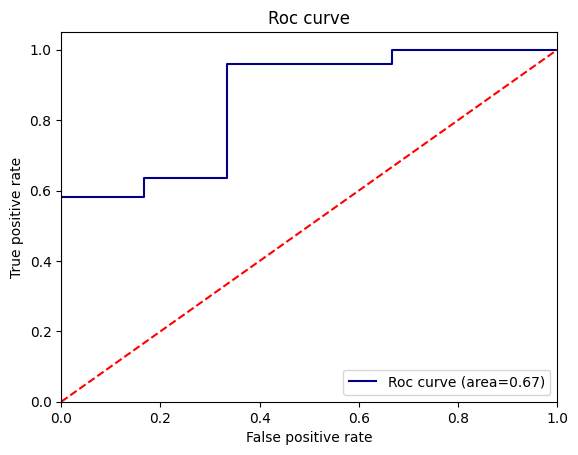

In [20]:
#plotting roc_auc curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, color='darkblue', lw=1.5, label='Roc curve (area=%0.2f)'%roc_auc_score(y_test, y_pred))
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc curve")
plt.legend()
plt.show()

In [22]:
#plot decision boundary
def plot_decision_boundary(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    
    z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, z, alpha=0.2)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title('Decision boundary')
    plt.show()

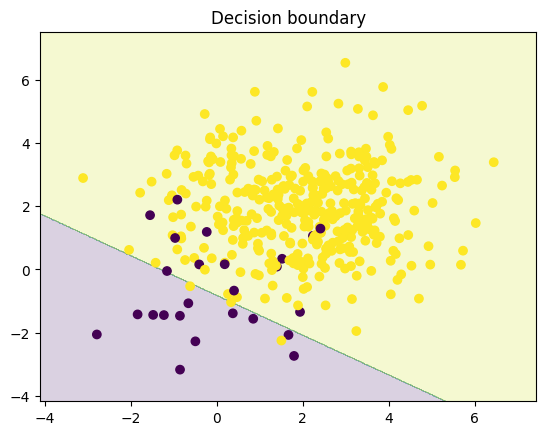

In [23]:
plot_decision_boundary(X, y, lr)

**Random undersampling**

In this approach, we randomly sample from dominant class in a way that the sample size will be equal to the non-dominant class

In [25]:
from imblearn.under_sampling import RandomUnderSampler

In [26]:
#applying under sampling technique
rus = RandomUnderSampler(random_state=19)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

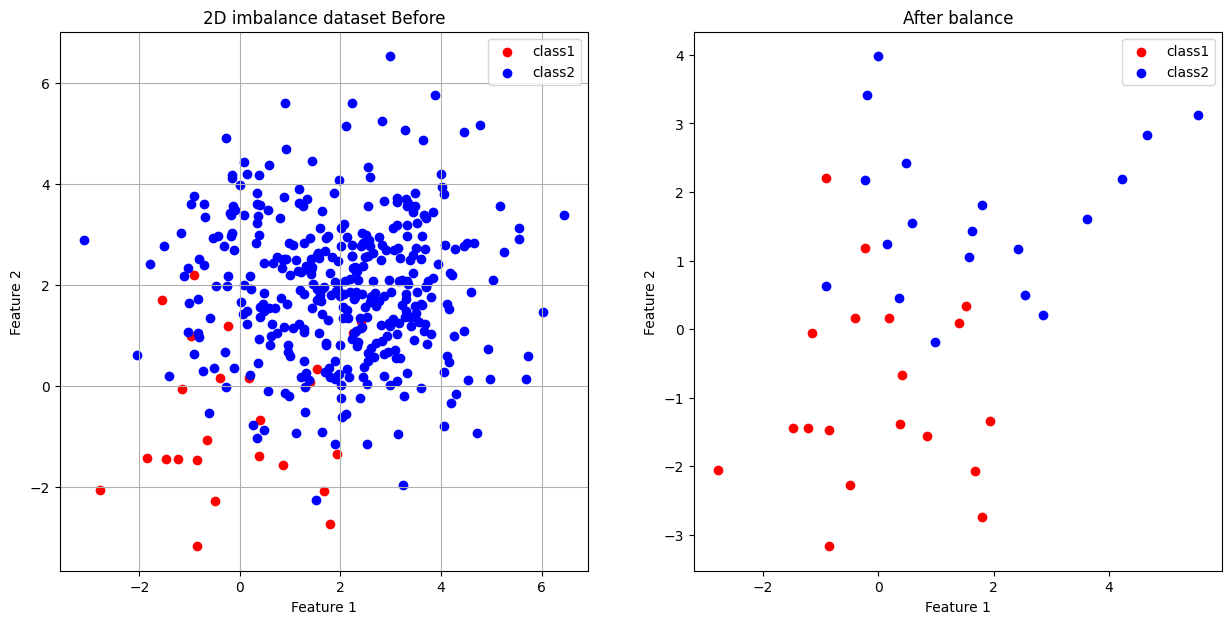

In [33]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='class1')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='class2')
plt.title("2D imbalance dataset Before")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(X_resampled[y_resampled==0][:, 0], X_resampled[y_resampled==0][:, 1], color='red', label='class1')
plt.scatter(X_resampled[y_resampled==1][:, 0], X_resampled[y_resampled==1][:, 1], color='blue', label='class2')
plt.title('After balance')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.show()

In [34]:
#now train the same logistic regression model for undersampling data
lg = LogisticRegression()
lg.fit(X_resampled, y_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
y_pred_rus = lg.predict(X_test)
y_rus_prod = lg.predict_proba(X_test)[:, 1]

In [75]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rus))
print(roc_auc_score(y_test, y_rus_prod))

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         6
           1       0.97      0.95      0.96        74

    accuracy                           0.93        80
   macro avg       0.74      0.81      0.77        80
weighted avg       0.94      0.93      0.93        80

0.8558558558558558


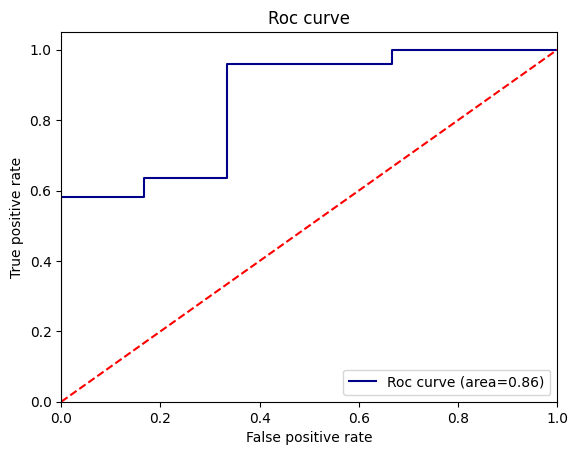

In [76]:
#plotting roc_auc curve
fpr, tpr, _ = roc_curve(y_test, y_rus_prod)
plt.figure()
plt.plot(fpr, tpr, color='darkblue', lw=1.5, label='Roc curve (area=%0.2f)'%roc_auc_score(y_test, y_rus_prod))
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc curve")
plt.legend()
plt.show()

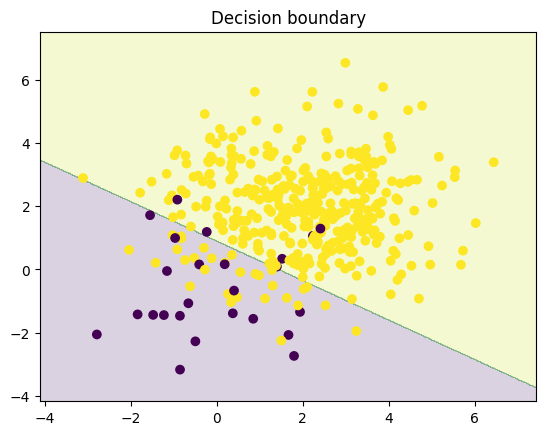

In [41]:
plot_decision_boundary(X, y, lg)

**Oversampling**

Making duplication of the class which has less data points until it get equal to the dominant class.

In [42]:
from imblearn.over_sampling import RandomOverSampler

In [43]:
oversampling = RandomOverSampler(random_state=19)

In [44]:
X_over_sample, y_over_sample = oversampling.fit_resample(X_train, y_train)

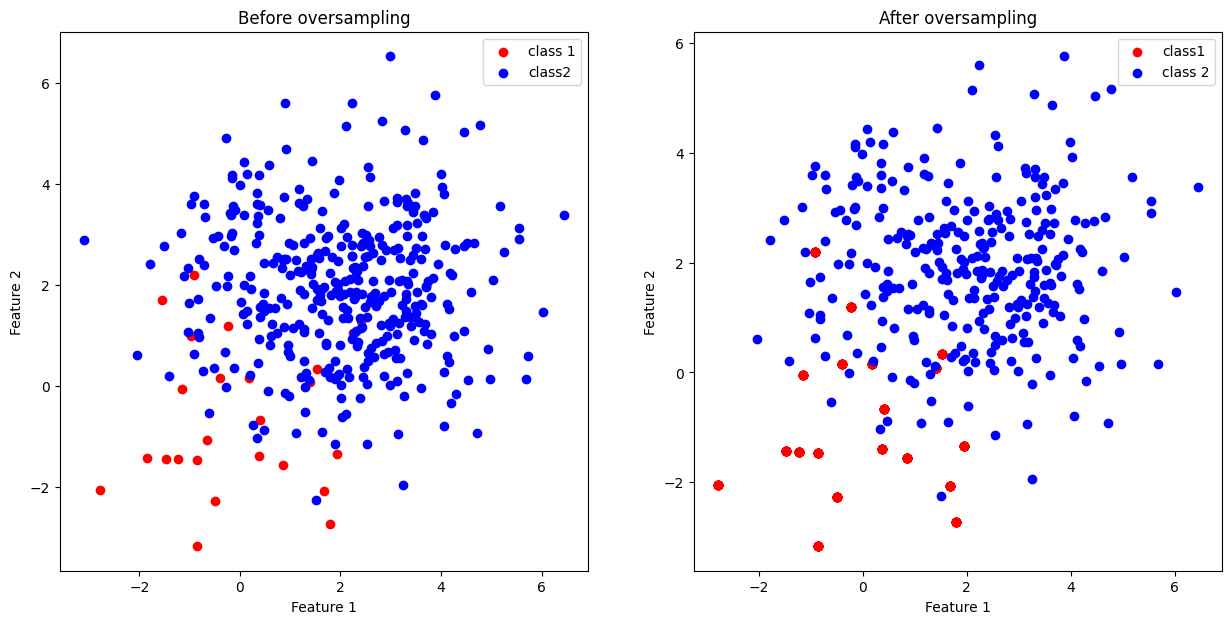

In [45]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='class 1')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='class2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Before oversampling')
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(X_over_sample[y_over_sample==0][:, 0], X_over_sample[y_over_sample==0][:, 1], color='red', label='class1')
plt.scatter(X_over_sample[y_over_sample==1][:, 0], X_over_sample[y_over_sample==1][:, 1], color='blue', label='class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('After oversampling')
plt.legend()

plt.show()

In above image, before and after applying the oversampling seems to be same but in reality after applying oversampling, there is overlapping of the data points. So that it seems to be same but in reality it works.

In [46]:
#to verify check its shape.
print(X_train.shape)
print(X_over_sample.shape)

(320, 2)
(602, 2)


In [47]:
#apply logistic regression for transformed data

logr = LogisticRegression()
logr.fit(X_over_sample, y_over_sample)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
y_pred_over = logr.predict(X_test)
y_prob_over = logr.predict_proba(X_test)[:, 1]

In [73]:
print('Classification Report')
print(classification_report(y_test, y_pred_over))
print(roc_auc_score(y_test, y_prob_over))

Classification Report
              precision    recall  f1-score   support

           0       0.44      0.67      0.53         6
           1       0.97      0.93      0.95        74

    accuracy                           0.91        80
   macro avg       0.71      0.80      0.74        80
weighted avg       0.93      0.91      0.92        80

0.8558558558558559


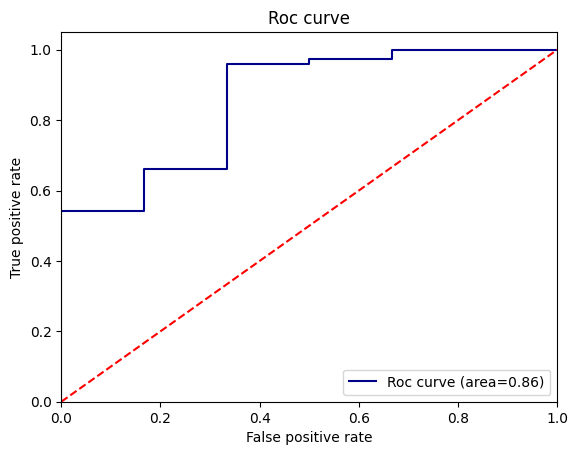

In [74]:
#plotting roc_auc curve
fpr, tpr, _ = roc_curve(y_test, y_prob_over)
plt.figure()
plt.plot(fpr, tpr, color='darkblue', lw=1.5, label='Roc curve (area=%0.2f)'%roc_auc_score(y_test, y_prob_over))
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc curve")
plt.legend()
plt.show()

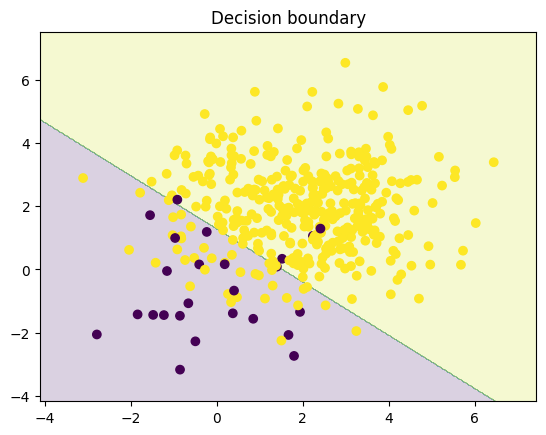

In [51]:
plot_decision_boundary(X, y, logr)

**SMOTE - Synthetic Minority Oversampling Technique**

Formula:

original sample - factor(original sample - neighbor)

In [52]:
from imblearn.over_sampling import SMOTE

In [53]:
smote = SMOTE(random_state=19)

In [54]:
X_smote, y_smote = smote.fit_resample(X_train, y_train)

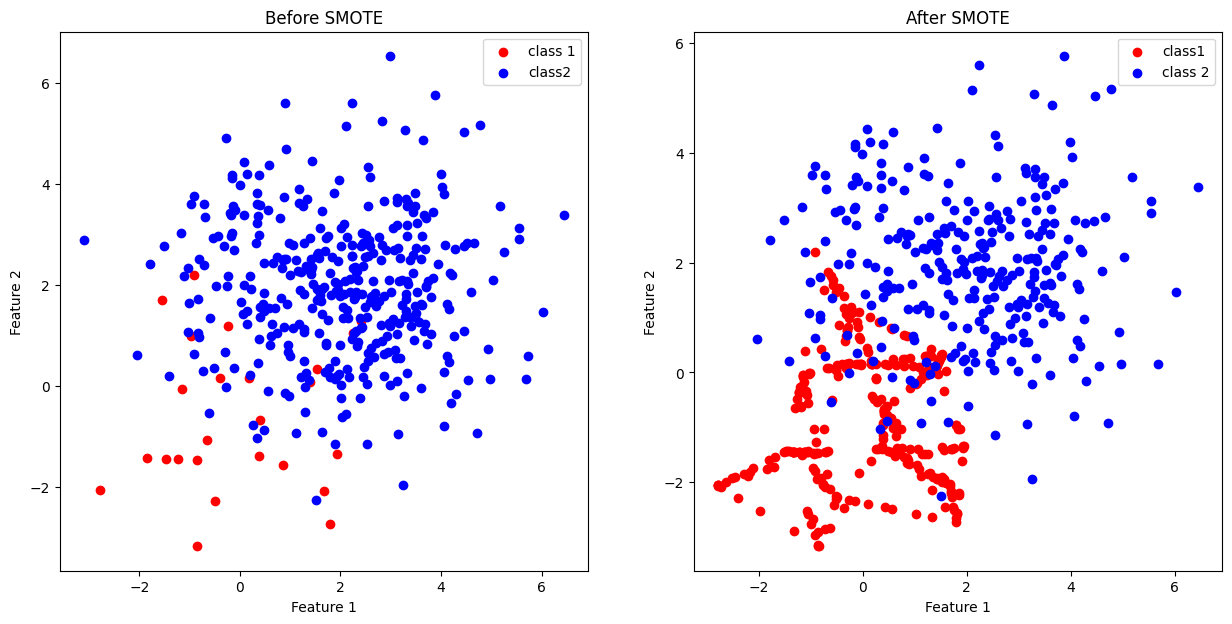

In [55]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='class 1')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='class2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Before SMOTE')
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(X_smote[y_smote==0][:, 0], X_smote[y_smote==0][:, 1], color='red', label='class1')
plt.scatter(X_smote[y_smote==1][:, 0], X_smote[y_smote==1][:, 1], color='blue', label='class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('After SMOTE')
plt.legend()

plt.show()

In [56]:
print(X_train.shape)
print(X_smote.shape)

(320, 2)
(602, 2)


In [57]:
#applying logistic regression
logistic = LogisticRegression()
logistic.fit(X_smote, y_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [58]:
y_pred_smote = logistic.predict(X_test)
y_prob_smote = logistic.predict_proba(X_test)[:, 1]

In [70]:
print("Classification Report:")
print(classification_report(y_test, y_pred_smote))
print(roc_auc_score(y_test, y_prob_smote))

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.67      0.53         6
           1       0.97      0.93      0.95        74

    accuracy                           0.91        80
   macro avg       0.71      0.80      0.74        80
weighted avg       0.93      0.91      0.92        80

0.8581081081081081


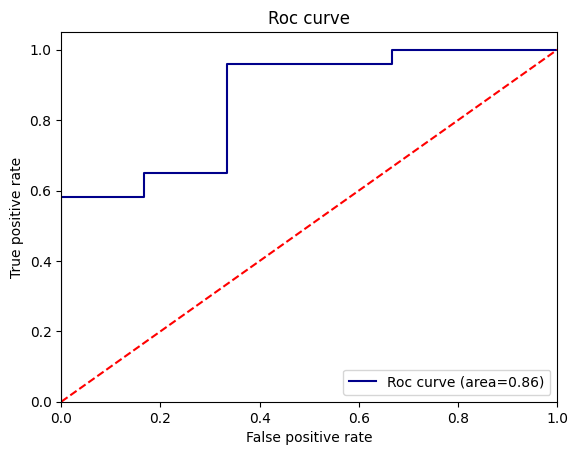

In [72]:
#plotting roc_auc curve
fpr, tpr, _ = roc_curve(y_test, y_prob_smote)
plt.figure()
plt.plot(fpr, tpr, color='darkblue', lw=1.5, label='Roc curve (area=%0.2f)'%roc_auc_score(y_test, y_prob_smote))
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc curve")
plt.legend()
plt.show()

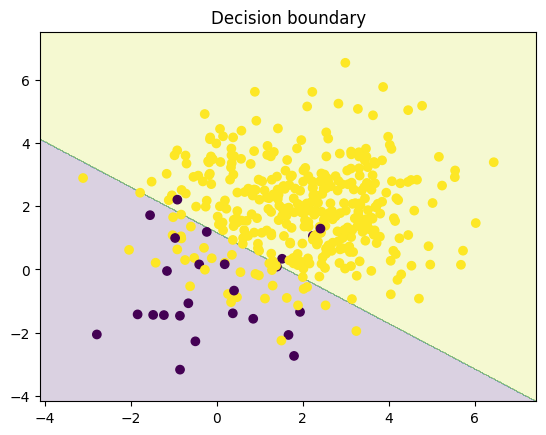

In [63]:
plot_decision_boundary(X, y, logistic)

**Disadvantage**

i. doesnot handle categorical data well

ii. computational complexity

iii. dependency on the choice of neighbors

iv. sensetive to outliers

v. balance achieved may not reflect true nature

**Balanced Random Forest**

In [65]:
from imblearn.ensemble import BalancedRandomForestClassifier
rf = BalancedRandomForestClassifier(random_state=19)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [67]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [68]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [69]:
print("classification report:")
print(classification_report(y_test, y_pred_rf))
print(roc_auc_score(y_test, y_prob_rf))

classification report:
              precision    recall  f1-score   support

           0       0.27      0.50      0.35         6
           1       0.96      0.89      0.92        74

    accuracy                           0.86        80
   macro avg       0.61      0.70      0.64        80
weighted avg       0.91      0.86      0.88        80

0.7477477477477478


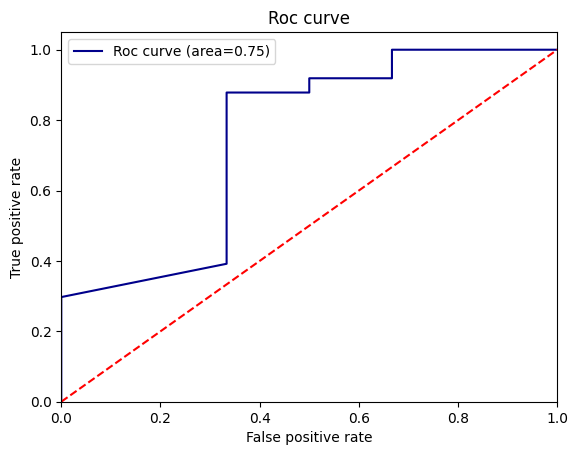

In [77]:
#plotting roc_auc curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure()
plt.plot(fpr, tpr, color='darkblue', lw=1.5, label='Roc curve (area=%0.2f)'%roc_auc_score(y_test, y_prob_rf))
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc curve")
plt.legend()
plt.show()

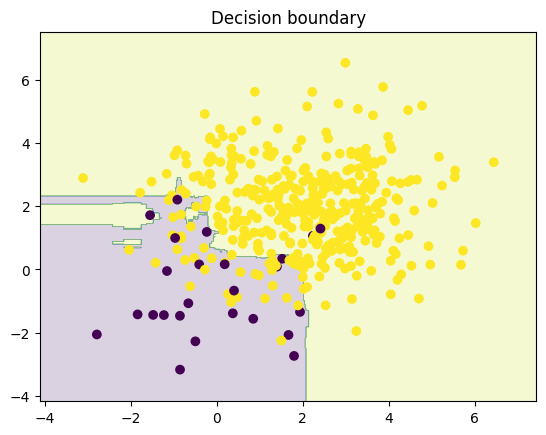

In [78]:
plot_decision_boundary(X, y, rf)

**Class Weights**

In [85]:
#create logistic regression model with class weights
logistic_reg = LogisticRegression(class_weight={0:50, 1:1}, solver='liblinear')

In [86]:
logistic_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 50, 1: 1}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For

In [87]:
y_pred_class = logistic_reg.predict(X_test)
y_prob_class = logistic_reg.predict_proba(X_test)[:, 1]

In [88]:
print('Classificatio Report:')
print(classification_report(y_test, y_pred_class))
print(roc_auc_score(y_test, y_prob_class))

Classificatio Report:
              precision    recall  f1-score   support

           0       0.17      0.67      0.28         6
           1       0.96      0.74      0.84        74

    accuracy                           0.74        80
   macro avg       0.57      0.70      0.56        80
weighted avg       0.91      0.74      0.80        80

0.8558558558558559


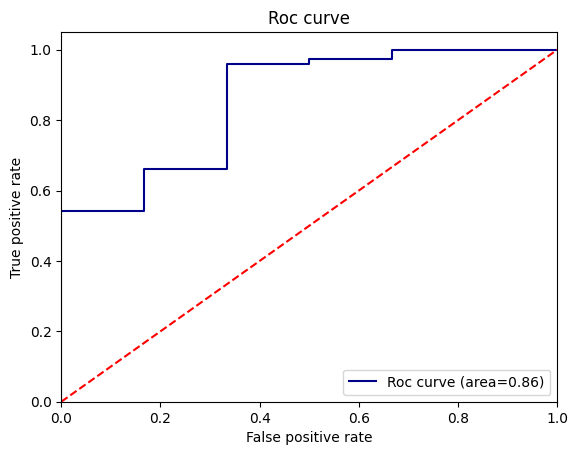

In [89]:
#plotting roc_auc curve
fpr, tpr, _ = roc_curve(y_test, y_prob_class)
plt.figure()
plt.plot(fpr, tpr, color='darkblue', lw=1.5, label='Roc curve (area=%0.2f)'%roc_auc_score(y_test, y_prob_class))
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc curve")
plt.legend()
plt.show()

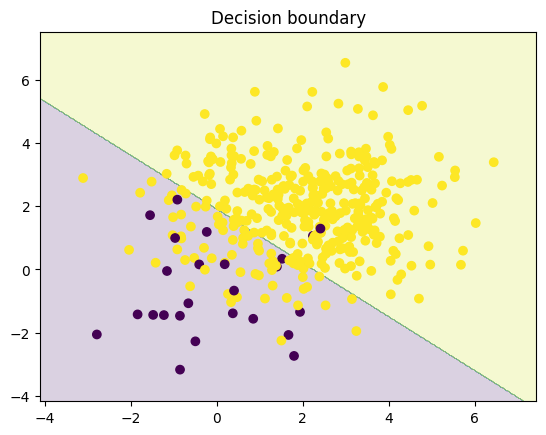

In [90]:
plot_decision_boundary(X, y, logistic_reg)

**Custom Loss Function**

In [91]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def custom_loss(preds, dtrain):
    labels = dtrain.get_label()
    preds = 1.0 / (1.0 + np.exp(-preds))  # Convert to probability

    # Define penalties
    false_positive_penalty = 10
    false_negative_penalty = 1.0

    grad = (preds - labels) * ((labels == 1) * false_negative_penalty + (labels == 0) * false_positive_penalty)
    hess = preds * (1 - preds) * ((labels == 1) * false_negative_penalty + (labels == 0) * false_positive_penalty)
    return grad, hess

# Convert to DMatrix object
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up parameters
params = {
    'max_depth': 3,
    'eta': 0.1,
    'silent': 1,
}

In [92]:
# Train the model
bst = xgb.train(params, dtrain, num_boost_round=10, obj=custom_loss)

# Predict test set
y_pred = np.where(bst.predict(dtest) > 0.5, 1, 0)
y_proba = bst.predict(dtest)  # Probability predictions

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\xgboost\core.py:751: UserWarning: [22:47:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  return func(**kwargs)


In [93]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print ROC AUC Score
auc_score = roc_auc_score(y_test, y_proba)
print("ROC AUC Score:", auc_score)

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.71      0.38         7
           1       0.98      0.88      0.93       113

    accuracy                           0.87       120
   macro avg       0.62      0.80      0.65       120
weighted avg       0.94      0.87      0.89       120

ROC AUC Score: 0.8482932996207333


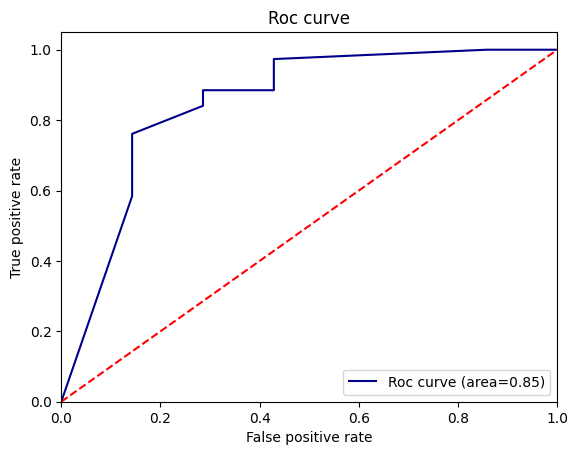

In [94]:
#plotting roc_auc curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkblue', lw=1.5, label='Roc curve (area=%0.2f)'%roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc curve")
plt.legend()
plt.show()

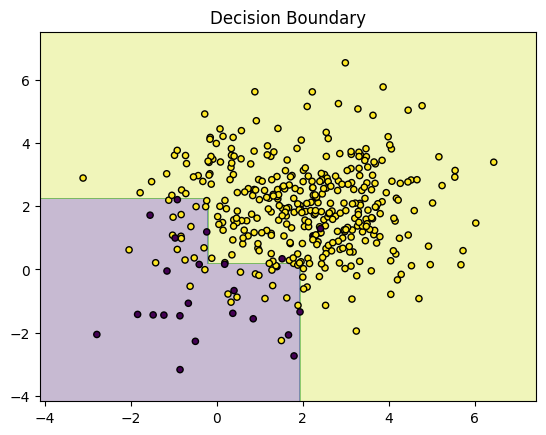

In [96]:
def plot_decision_boundaries(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(xgb.DMatrix(np.c_[xx.ravel(), yy.ravel()]))
    Z = np.where(Z > 0.5, 1, 0).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()

# Plot decision boundary
plot_decision_boundaries(X, y, bst)